# JAWAD HASSAN
# 2230-0035
# BS AI
# ML
# LAB 04
# K NEAREST NEIGHBOUR LAB TASK:

In [26]:
#import libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix,ConfusionMatrixDisplay
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [21]:
#q1-data preprocessing:
x=load_iris().data
y=load_iris().target
xfeature=load_iris().feature_names
df=pd.DataFrame(x,columns=xfeature)
df['species']=y
ytarget=load_iris().target_names
print('features:',xfeature)
print('labels:',ytarget)
print(df.head())
print(df.isnull().sum())
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)
scalar=StandardScaler()
xtrainscaled=scalar.fit_transform(xtrain)
xtestscaled=scalar.transform(xtest)

features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
labels: ['setosa' 'versicolor' 'virginica']
   sepal length (cm)  sepal width (cm)  ...  petal width (cm)  species
0                5.1               3.5  ...               0.2        0
1                4.9               3.0  ...               0.2        0
2                4.7               3.2  ...               0.2        0
3                4.6               3.1  ...               0.2        0
4                5.0               3.6  ...               0.2        0

[5 rows x 5 columns]
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [22]:
#q2-knn model training:
k_list=[1,3,5,7,9]
for k in k_list:
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(xtrainscaled,ytrain)
    ypred=knn.predict(xtestscaled)
    acc = accuracy_score(ytest, ypred)
    print(f"K = {k}: Accuracy = {acc:.2f}")

K = 1: Accuracy = 1.00
K = 3: Accuracy = 1.00
K = 5: Accuracy = 1.00
K = 7: Accuracy = 1.00
K = 9: Accuracy = 1.00


In [ ]:
#q3-model evaluation:
knn5=KNeighborsClassifier(n_neighbors=5)
knn5.fit(xtrainscaled,ytrain)
ypred5=knn5.predict(xtestscaled)
acc=accuracy_score(ytest,ypred5)
recall=recall_score(ytest,ypred5,average='weighted')
precision=precision_score(ytest,ypred5,average='weighted')
f1=f1_score(ytest,ypred5,average='weighted')
print(f"K = 5: Accuracy = {acc:.2f}, Recall = {recall:.2f}, Precision = {precision:.2f}, F1 Score = {f1:.2f}")
print('confusion matrix:\n',confusion_matrix(ytest,ypred5))


K = 5: Accuracy = 1.00, Recall = 1.00, Precision = 1.00, F1 Score = 1.00
confusion matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


<Figure size 800x600 with 0 Axes>

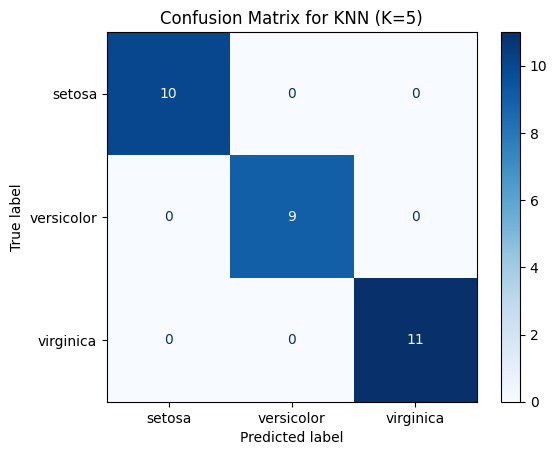

In [30]:
#q4-visualization:
plt.figure(figsize=(8,6))
ConfusionMatrixDisplay.from_predictions(ytest,ypred5,display_labels=ytarget,cmap=plt.cm.Blues)
plt.title('Confusion Matrix for KNN (K=5)')
plt.show()

In [34]:
#decision tree model training and evaluation:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(random_state=42)
dt.fit(xtrainscaled,ytrain)
ypred=dt.predict(xtestscaled)
a=accuracy_score(ytest,ypred)
print(f"Accuracy of Decision Tree: {a:.2f}")
r=recall_score(ytest,ypred,average='macro')
p=precision_score(ytest,ypred,average='macro')
f1= f1_score(ytest,ypred,average='macro')
print(f"Recall: {r:.2f}, Precision: {p:.2f}, F1 Score: {f1:.2f}")


Accuracy of Decision Tree: 1.00
Recall: 1.00, Precision: 1.00, F1 Score: 1.00
